In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 03
## FIFA dataset 

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
import tensorflow as tf
# from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
# print (fn_plot_torch_hist.__doc__)

In [4]:
# print (fn_plot_confusion_matrix.__doc__)

In [5]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 101 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2

# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'medium',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [6]:
# Check if all directories are present
outDir.mkdir(parents=True, exist_ok=True)

modelSubDir = modelDir/ subDir
modelSubDir.mkdir(parents=True, exist_ok=True)

## Read FIFA 2019 data set

In [7]:
data_df = pd.read_csv('fifa_2019.csv')
data_df.columns

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingT

In [8]:
# removing rows with position = null
data_df = data_df[data_df["Position"].notnull()]
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [9]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [10]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [11]:
data_df=data_df[rel_cols]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [12]:
#Assign labels to goalkeepers
data_df['Position_encoded']=0
data_df.loc[data_df["Position"] == "GK", "Position_encoded"] = 0

#Defenders
data_df.loc[data_df["Position"].isin(defender), "Position_encoded"] = 1

#Midfielders
data_df.loc[data_df["Position"].isin(midfielder), "Position_encoded"] = 2

#Forward
data_df.loc[data_df["Position"].isin(forward), "Position_encoded"] = 3

# Convert Column "Position" to numeric so that Pandas does not complain
data_df['Position_encoded'] = pd.to_numeric(data_df['Position_encoded'], downcast="integer")

In [13]:
labels=data_df['Position_encoded']
features=data_df.drop(['Position','Position_encoded'],axis=1)

In [14]:
class_names = {0: 'Goal Keeper', 1: 'Defender', 2: 'Mid-Fielder', 3: 'Forward'}

In [15]:
# splitting in train ans test datasets
X_train, X_test,y_train, y_test = train_test_split(features,labels,
                                     stratify=labels,
                                     test_size=TEST_SIZE, 
                                     random_state=RANDOM_STATE )
X_train.shape, X_test.shape,y_train.shape, y_test.shape

((14517, 33), (3630, 33), (14517,), (3630,))

In [16]:
list(class_names.keys())

[0, 1, 2, 3]

In [17]:
train_ds=tf.data.Dataset.from_tensor_slices((X_train.to_numpy(),
                                           y_train.to_numpy()))
test_ds=tf.data.Dataset.from_tensor_slices((X_test.to_numpy(),
                                           y_test.to_numpy()))
type(train_ds),type(test_ds)

(tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset,
 tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset)

### Predprocessing and Batching

In [18]:
train_ds=train_ds.cache()
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)

test_ds=test_ds.cache()
test_ds=test_ds.prefetch(tf.data.AUTOTUNE)

In [19]:
train_ds=train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)

test_ds=test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [20]:
for features,lebels in train_ds.take(1):
    print(features.shape,labels.shape)

(32, 33) (18147,)


In [21]:
normalizer=tf.keras.layers.Normalization(axis=1)
normalizer.adapt(X_train.to_numpy())

In [22]:
normalizer.mean.numpy()

array([[45.520493, 52.243782, 58.685886, 42.902115, 55.379074, 47.15747 ,
        42.83013 , 52.761726, 58.392986, 64.649925, 64.79913 , 63.53792 ,
        61.809742, 63.964455, 55.430115, 65.06902 , 63.24902 , 65.372665,
        47.119926, 55.8727  , 46.72701 , 49.943306, 53.40263 , 48.518635,
        58.645657, 47.280293, 47.679203, 45.641525, 16.618792, 16.377558,
        16.216711, 16.372667, 16.711098]], dtype=float32)

In [23]:
normalizer.variance.numpy()

array([[381.27637, 302.225  , 216.46509, 314.4344 , 358.05862, 338.72565,
        305.6274 , 233.78761, 277.84177, 220.56754, 213.31131, 217.05934,
         81.14435, 199.90918, 297.45694, 139.75758, 252.52716, 157.12006,
        371.17862, 301.67438, 426.03412, 381.6611 , 201.29845, 245.74033,
        130.18896, 396.54602, 468.74197, 451.3309 , 312.67398, 285.4781 ,
        271.2175 , 288.47983, 321.72186]], dtype=float32)

In [24]:
inputs=tf.keras.Input(shape=(X_train.shape[1],))
x=normalizer(inputs)
x=tf.keras.layers.Dense(16,activation='relu')(x)
x=tf.keras.layers.Dense(8,activation='relu')(x)
outputs=tf.keras.layers.Dense(4)(x)
model=tf.keras.Model(inputs=inputs,outputs=outputs)

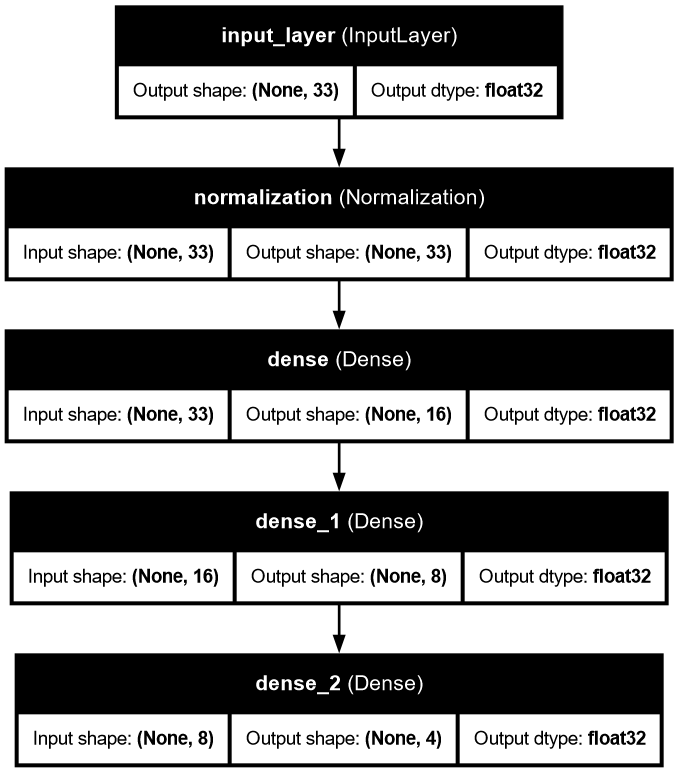

In [25]:
tf.keras.utils.plot_model(model,
                          to_file=modelSubDir/'tf_fifa.png',
                          show_shapes=True,
                          show_dtype=True,
                          show_layer_names=True,
                          expand_nested=True,
                          dpi=96)

In [26]:
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)

model.compile(optimizer=optimizer,
             loss=loss_fn,
             metrics=['accuracy'])
history=model.fit(train_ds,
                 epochs=EPOCHS,
                 batch_size=BATCH_SIZE,
                 validation_data=test_ds)

Epoch 1/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7139 - loss: 0.6280 - val_accuracy: 0.8300 - val_loss: 0.3856
Epoch 2/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8606 - loss: 0.3412 - val_accuracy: 0.8581 - val_loss: 0.3360
Epoch 3/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8710 - loss: 0.3183 - val_accuracy: 0.8656 - val_loss: 0.3230
Epoch 4/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8764 - loss: 0.3080 - val_accuracy: 0.8623 - val_loss: 0.3191
Epoch 5/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.3014 - val_accuracy: 0.8620 - val_loss: 0.3148
Epoch 6/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8795 - loss: 0.2972 - val_accuracy: 0.8645 - val_loss: 0.3101
Epoch 7/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8816 - loss: 0.2932 - val_accuracy: 0.8672 - val_loss: 0.3065
Epoch 8/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8813 - loss: 0.2905 - val_accu

In [27]:
###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    


In [28]:
loss_df=pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.713853,0.628013,0.830028,0.385638
1,0.860646,0.341170,0.858127,0.335999
2,0.870979,0.318337,0.865565,0.322977
3,0.876352,0.308004,0.862259,0.319084
4,0.878625,0.301445,0.861983,0.314850


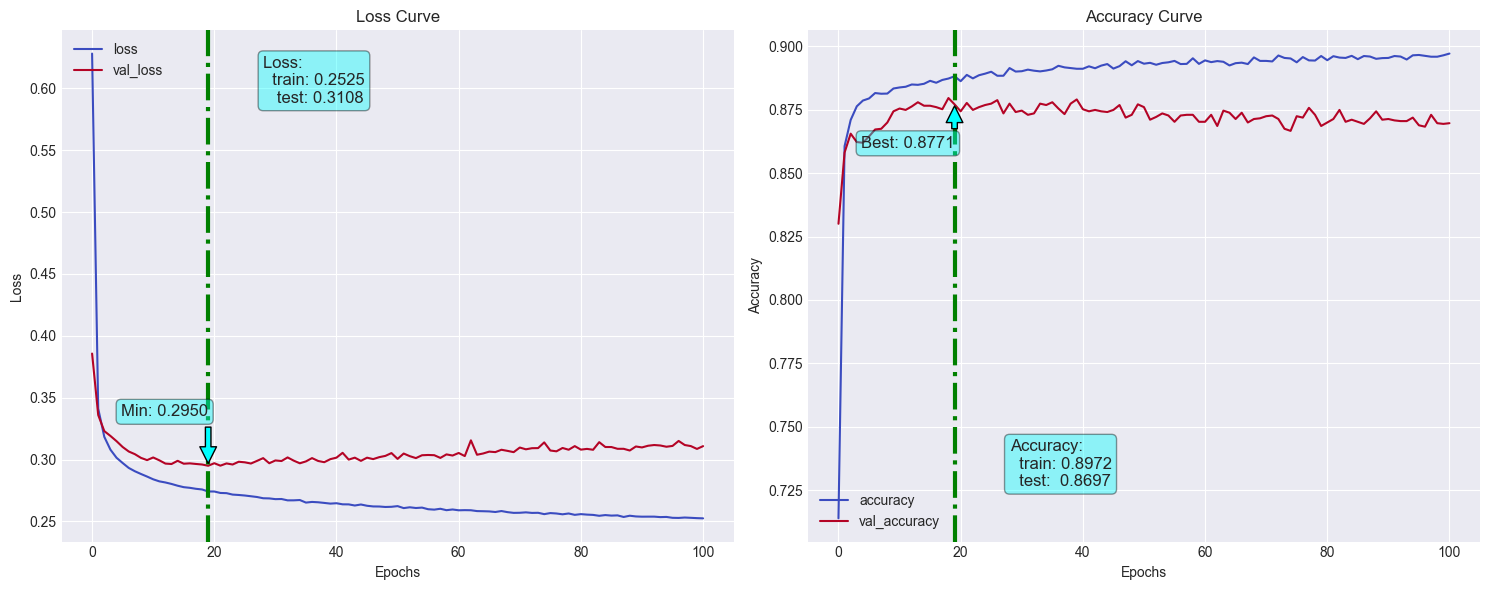

In [29]:
fn_plot_tf_hist(loss_df)

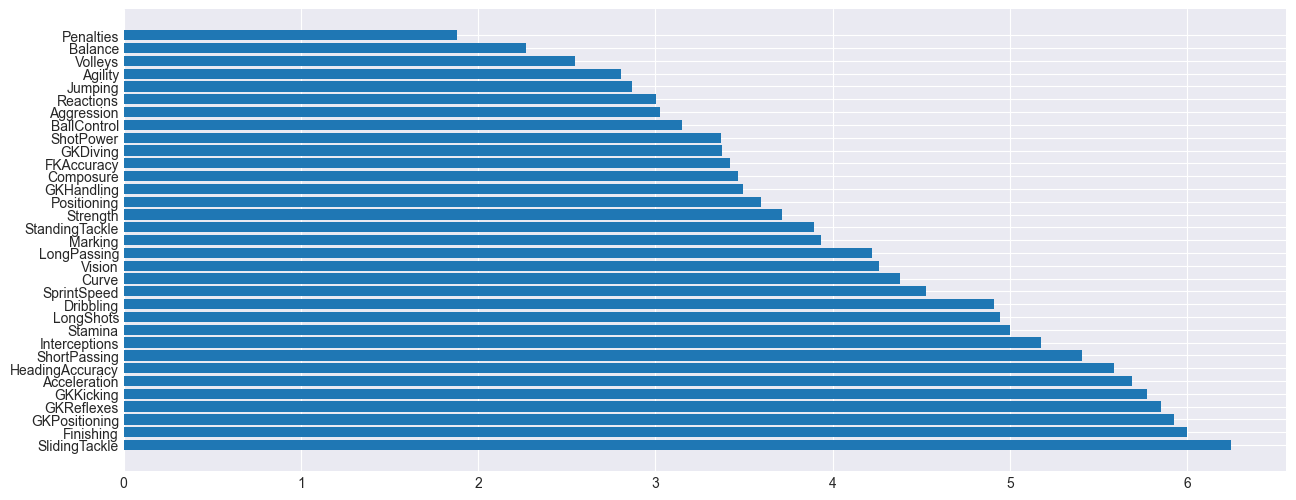

In [30]:
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        first_kernel=layer
        break

weights,bias=first_kernel.get_weights()
weights.shape,bias.shape
features_importance=np.abs(weights).sum(axis=1)
features_df=pd.DataFrame({'feature':X_train.columns,
                         'importance':features_importance})

features_df=features_df.sort_values(by='importance',ascending=True)
fig,ax=plt.subplots()
ax.barh(features_df['feature'],features_df['importance'])
plt.gca().invert_yaxis()

In [39]:
y_true,y_pred=[],[]
for features,labels in train_ds:
    pred=model(features, training=False)
    pred=pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
y_true=np.concatenate(y_true)
y_pred=np.concatenate(y_pred)
accuracy_score(y_true,y_pred)

0.8981883309223668

In [40]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1620
           1       0.93      0.94      0.93      4693
           2       0.86      0.87      0.87      5470
           3       0.86      0.82      0.84      2734

    accuracy                           0.90     14517
   macro avg       0.91      0.91      0.91     14517
weighted avg       0.90      0.90      0.90     14517



In [41]:
y_true,y_pred=[],[]
for features,labels in test_ds:
    pred=model(features, training=False)
    y_pred.append(tf.argmax(pred,axis=1).numpy())
    y_true.append(labels.numpy())
    
y_true=np.concatenate(y_true)
y_pred=np.concatenate(y_pred)
accuracy_score(y_true,y_pred)

0.8696969696969697

In [42]:
y_true,y_pred=[],[]
for features,labels in train_ds:
    pred=model(features, training=False)
    pred=pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
y_true=np.concatenate(y_true)
y_pred=np.concatenate(y_pred)
accuracy_score(y_true,y_pred)

0.8981883309223668

In [47]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true,y_pred, average='weighted'):0.4f}")
    plt.show()

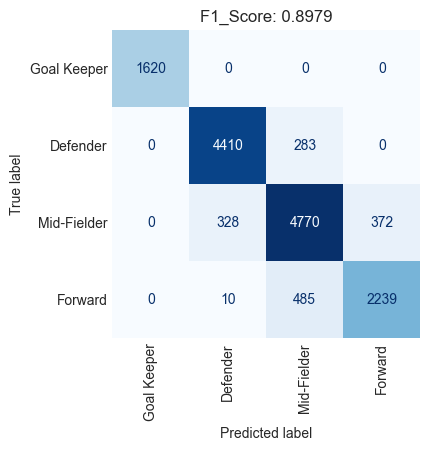

In [48]:
class_labels = {0: 1, 1:2, 2:3}
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)